In [17]:
import os
from glob import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json

In [14]:
metrics_json_paths = glob('./logs/finetune_20250624/*/*/*/*/*/*/*/*/*/*/assessment_metrics.json')
print(f'Found {len(metrics_json_paths)} metrics JSON files.')

Found 252 metrics JSON files.


In [25]:
metrics_records = []
for metrics_json in metrics_json_paths:
    split_path_parts = metrics_json.split(os.sep)
    model = split_path_parts[3]
    pretrain_method = split_path_parts[4]
    frozen_encoder = split_path_parts[9] == 'frozenencoder_true'
    n_train = split_path_parts[10]
    fold = split_path_parts[11].split('_')[-1]
    
    metrics = json.load(open(metrics_json, 'r'))
    metrics['model'] = model
    metrics['pretrain_method'] = pretrain_method
    metrics['frozen_encoder'] = frozen_encoder
    metrics['n_train'] = n_train
    metrics['fold'] = fold
    metrics_records.append(metrics)

metrics_df = pd.DataFrame(metrics_records)
display(metrics_df.sort_values(by='macro_f1_score', ascending=False))

,accuracy,f1_score,precision,recall,jaccard,kappa,cross_entropy,brier_score,macro_f1_score,macro_precision,...,weighted_precision,weighted_recall,weighted_jaccard,weighted_cross_entropy,weighted_brier_score,model,pretrain_method,frozen_encoder,n_train,fold
104,0.877285,0.877285,0.877285,0.877285,0.781396,0.786588,1.597399,0.030271,0.763355,0.784741,...,0.874143,0.877285,0.788331,1.597399,0.030271,unet,byol,False,500,2
118,0.876125,0.876125,0.876125,0.876125,0.779557,0.783074,1.599033,0.030126,0.759095,0.793655,...,0.875439,0.876125,0.785273,1.599033,0.030126,unet,imagenet,True,500,2
90,0.878285,0.878285,0.878285,0.878285,0.782984,0.787727,1.602583,0.030539,0.757672,0.790188,...,0.876836,0.878285,0.789780,1.602583,0.030539,unet,byol,True,500,2
106,0.877205,0.877205,0.877205,0.877205,0.781269,0.785969,1.641316,0.034199,0.754727,0.787877,...,0.876351,0.877205,0.788262,1.641316,0.034199,unet,byol,False,500,6
123,0.875765,0.875765,0.875765,0.875765,0.778987,0.781706,1.627001,0.032493,0.754038,0.791342,...,0.875673,0.875765,0.784577,1.627001,0.032493,unet,imagenet,True,750,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68,0.605896,0.605896,0.605896,0.605896,0.434613,0.158936,1.867128,0.076330,0.156777,0.225794,...,0.482341,0.605896,0.412355,1.867128,0.076330,linear_probe,none,True,750,2
59,0.580617,0.580617,0.580617,0.580617,0.409063,0.069983,1.868906,0.077107,0.155377,0.209834,...,0.447928,0.580617,0.380187,1.868906,0.077107,linear_probe,none,True,250,1
61,0.596496,0.596496,0.596496,0.596496,0.425005,0.108165,1.863478,0.076191,0.149033,0.215736,...,0.462988,0.596496,0.396347,1.863478,0.076191,linear_probe,none,True,500,3
58,0.589216,0.589216,0.589216,0.589216,0.417652,0.110705,1.868510,0.077014,0.139476,0.226392,...,0.467553,0.589216,0.393837,1.868510,0.077014,linear_probe,none,True,250,2


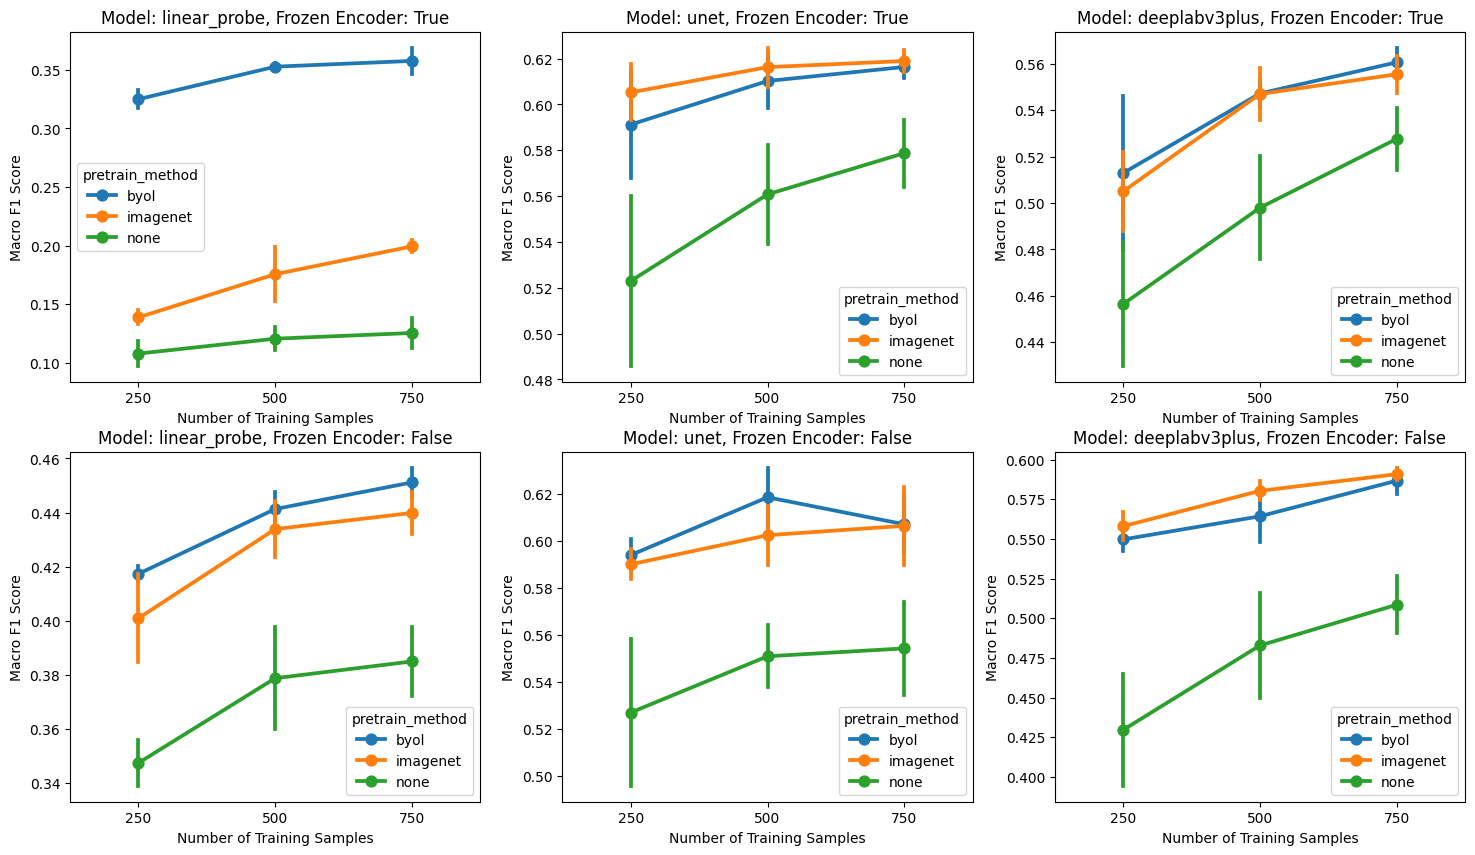

In [ ]:
import seaborn as sns

fig, ax = plt.subplots(2, 3, figsize=(18, 10))

for i, frozen_encoder in enumerate(metrics_df['frozen_encoder'].unique()):
    # print(i, model)
    for j, model in enumerate(metrics_df['model'].unique()):
        # metrics_df['model']
        # print(j, frozen_encoder)
        subset = metrics_df[(metrics_df['model'] == model) & (metrics_df['frozen_encoder'] == frozen_encoder)]
        # sns.lineplot(data=subset, x='n_train', y='macro_f1_score', hue='pretrain_method', ax=ax[i, j])
        # sns.catplot(data=subset, x='n_train', y='macro_f1_score', hue='pretrain_method', kind='point', ax=ax[i, j], markers=['o', 's', 'D'], linestyles=['-', '--', ':'])
        sns.pointplot(data=subset, x='n_train', y='macro_jaccard', hue='pretrain_method', ax=ax[i, j], dodge=False, errorbar='sd')
        ax[i, j].set_title(f'Model: {model}, Frozen Encoder: {frozen_encoder}')
        ax[i, j].set_xlabel('Number of Training Samples')
        ax[i, j].set_ylabel('mIOU')